# Point Tree Visualization

This notebook focuses on the runtime point graph used by multi-compartment cells.

A `NodeTree` is built after `Cell.init_state()` and exposes the execution-oriented node-edge topology used by the runtime.

In this notebook we will:

1. build a `Cell` and inspect its `NodeTree`
2. render node / CV / branch topology views from `Cell`
3. compare layouts, coverage modes, and runtime value colouring
4. summarize the level capabilities and most useful parameters


In [1]:
import os
from collections import deque

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainunit as u
import braincell.mech as mech
import braincell.vis as vis
import matplotlib.pyplot as plt
import numpy as np

from braincell import Cell, Morphology, MaxCVLen
from braincell.filter import BranchInFilter, BranchSlice, RootLocation, Terminals


## 1. Build a `NodeTree`

We start from a morphology, choose a CV policy that creates a reasonably dense discretization, initialize the cell, and retrieve the runtime `NodeTree`.


In [2]:
morpho = Morphology.from_asc("../../data/cerebellum/pc_ma2024/morphology/PC.asc")
# morpho.vis3d(jupyter_backend="html")
cell = Cell(
    morpho,
    cv_policy=MaxCVLen(25.0 * u.um),
)
cell.init_state()

node_tree = cell.node_tree

print(cell)
print(node_tree)
print("n_nodes:", len(node_tree.nodes))
print("n_edges:", len(node_tree.edges))
print("root_node_id:", node_tree.root_node_id)


--No graphics will be displayed.
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [6]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [8]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [4]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_poi

Cell(root='soma', n_cv=483, n_point=945, initialized=True)
-----------------------------------
n_nodes        | 945
n_edges        | 944
root_node_id   | 0
-----------------------------------

n_nodes: 945
n_edges: 944
root_node_id: 0


## 2. Default node-level topology view

The main user-facing entry point is now the cell-level API:

- `vis.plot_cell_topology(cell, ...)`
- or the thin dispatcher `vis.plot_cell_topology(cell, level="node", ...)`

The default preset is `"dendrotweaks"`, which uses a topology-only layout and ignores physical length and radius.


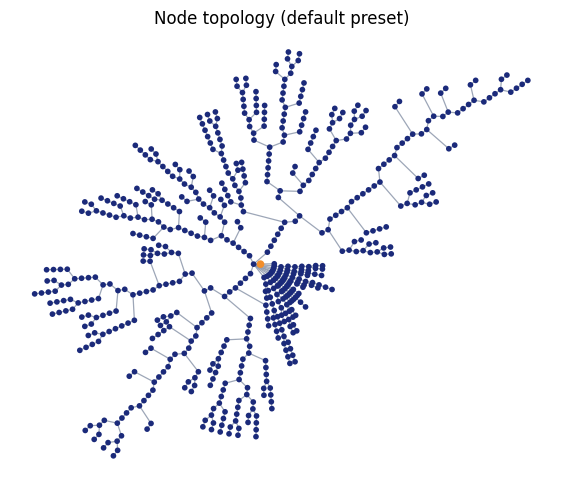

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
vis.plot_cell_topology(cell, ax=ax)
ax.set_title("Node topology (default preset)")
plt.show()


## 3. Compare presets and layouts

Available presets in this build:

- `dendrotweaks`
- `mono`
- `depth`

Available layouts in this build:

- `twopi`
- `dot`
- `neato`
- `kamada_kawai`


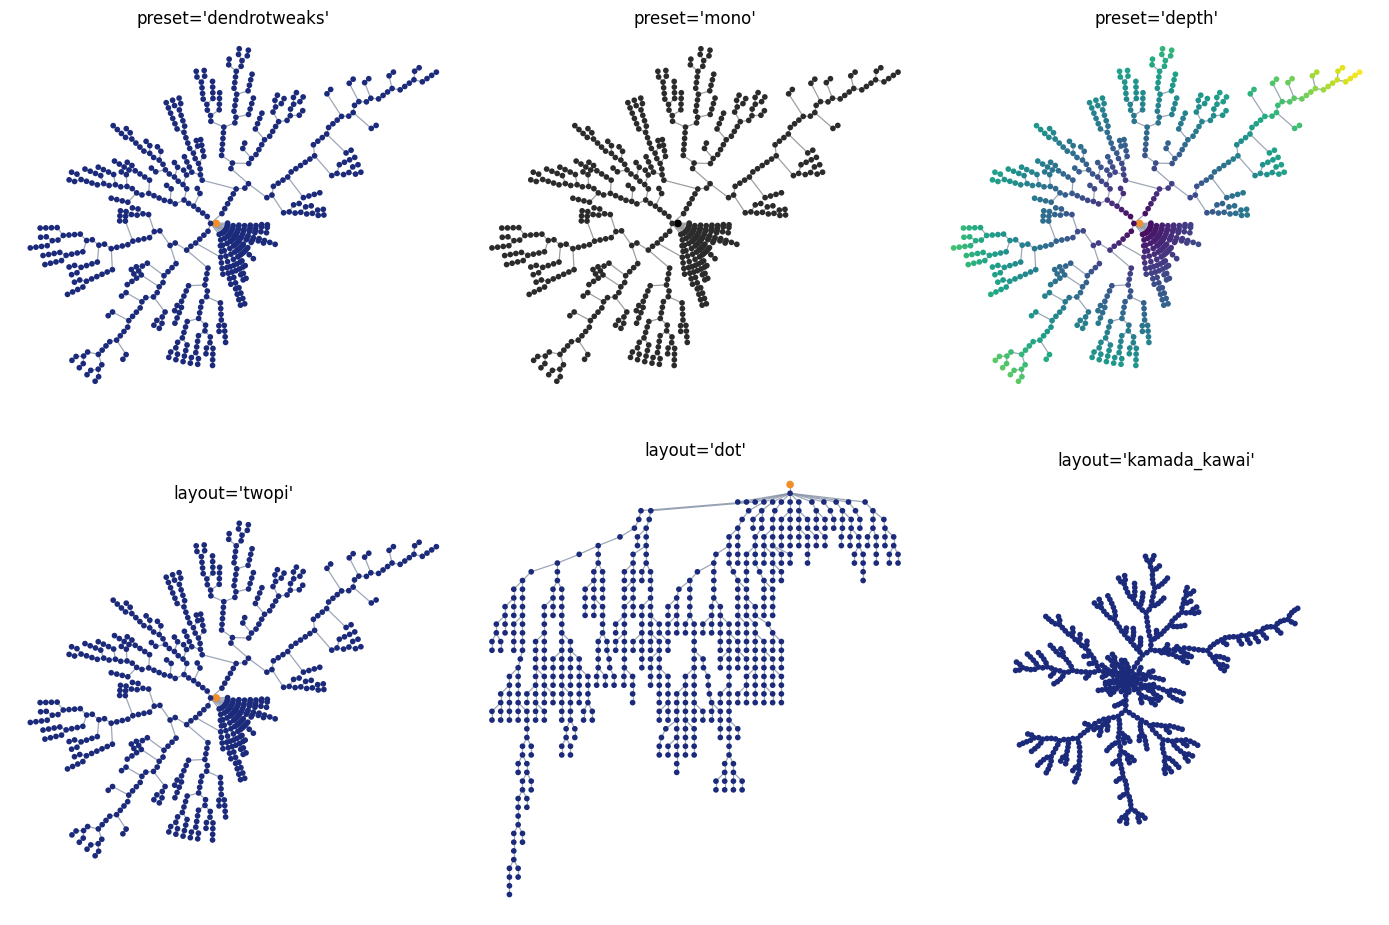

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

vis.plot_cell_topology(cell, level="node", preset="dendrotweaks", ax=axes[0, 0])
axes[0, 0].set_title("preset='dendrotweaks'")

vis.plot_cell_topology(cell, level="node", preset="mono", ax=axes[0, 1])
axes[0, 1].set_title("preset='mono'")

vis.plot_cell_topology(cell, level="node", preset="depth", ax=axes[0, 2])
axes[0, 2].set_title("preset='depth'")

vis.plot_cell_topology(cell, level="node", layout="twopi", ax=axes[1, 0])
axes[1, 0].set_title("layout='twopi'")

vis.plot_cell_topology(cell, level="node", layout="dot", ax=axes[1, 1])
axes[1, 1].set_title("layout='dot'")

vis.plot_cell_topology(cell, level="node", layout="kamada_kawai", ax=axes[1, 2])
axes[1, 2].set_title("layout='kamada_kawai'")

plt.tight_layout()
plt.show()


### Global spacing with `layout_scale`

`layout_scale` changes the overall point spacing for the resolved layout.

- smaller than `1.0`: tighter graph
- larger than `1.0`: more spread out graph


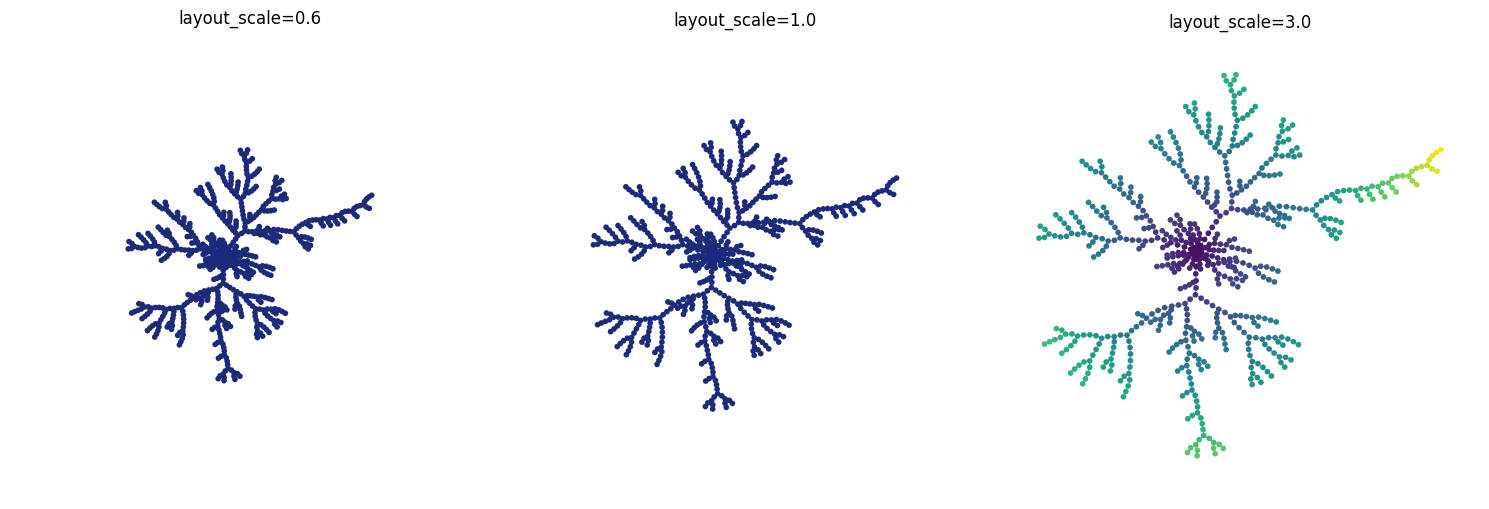

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vis.plot_cell_topology(cell, layout="kamada_kawai", layout_scale=0.6, ax=axes[0])
axes[0].set_title("layout_scale=0.6")

vis.plot_cell_topology(cell, layout="kamada_kawai", layout_scale=1.0, ax=axes[1])
axes[1].set_title("layout_scale=1.0")

vis.plot_cell_topology(cell, preset="depth", layout="kamada_kawai", layout_scale=3.0, ax=axes[2])
axes[2].set_title("layout_scale=3.0")

plt.tight_layout()
plt.show()


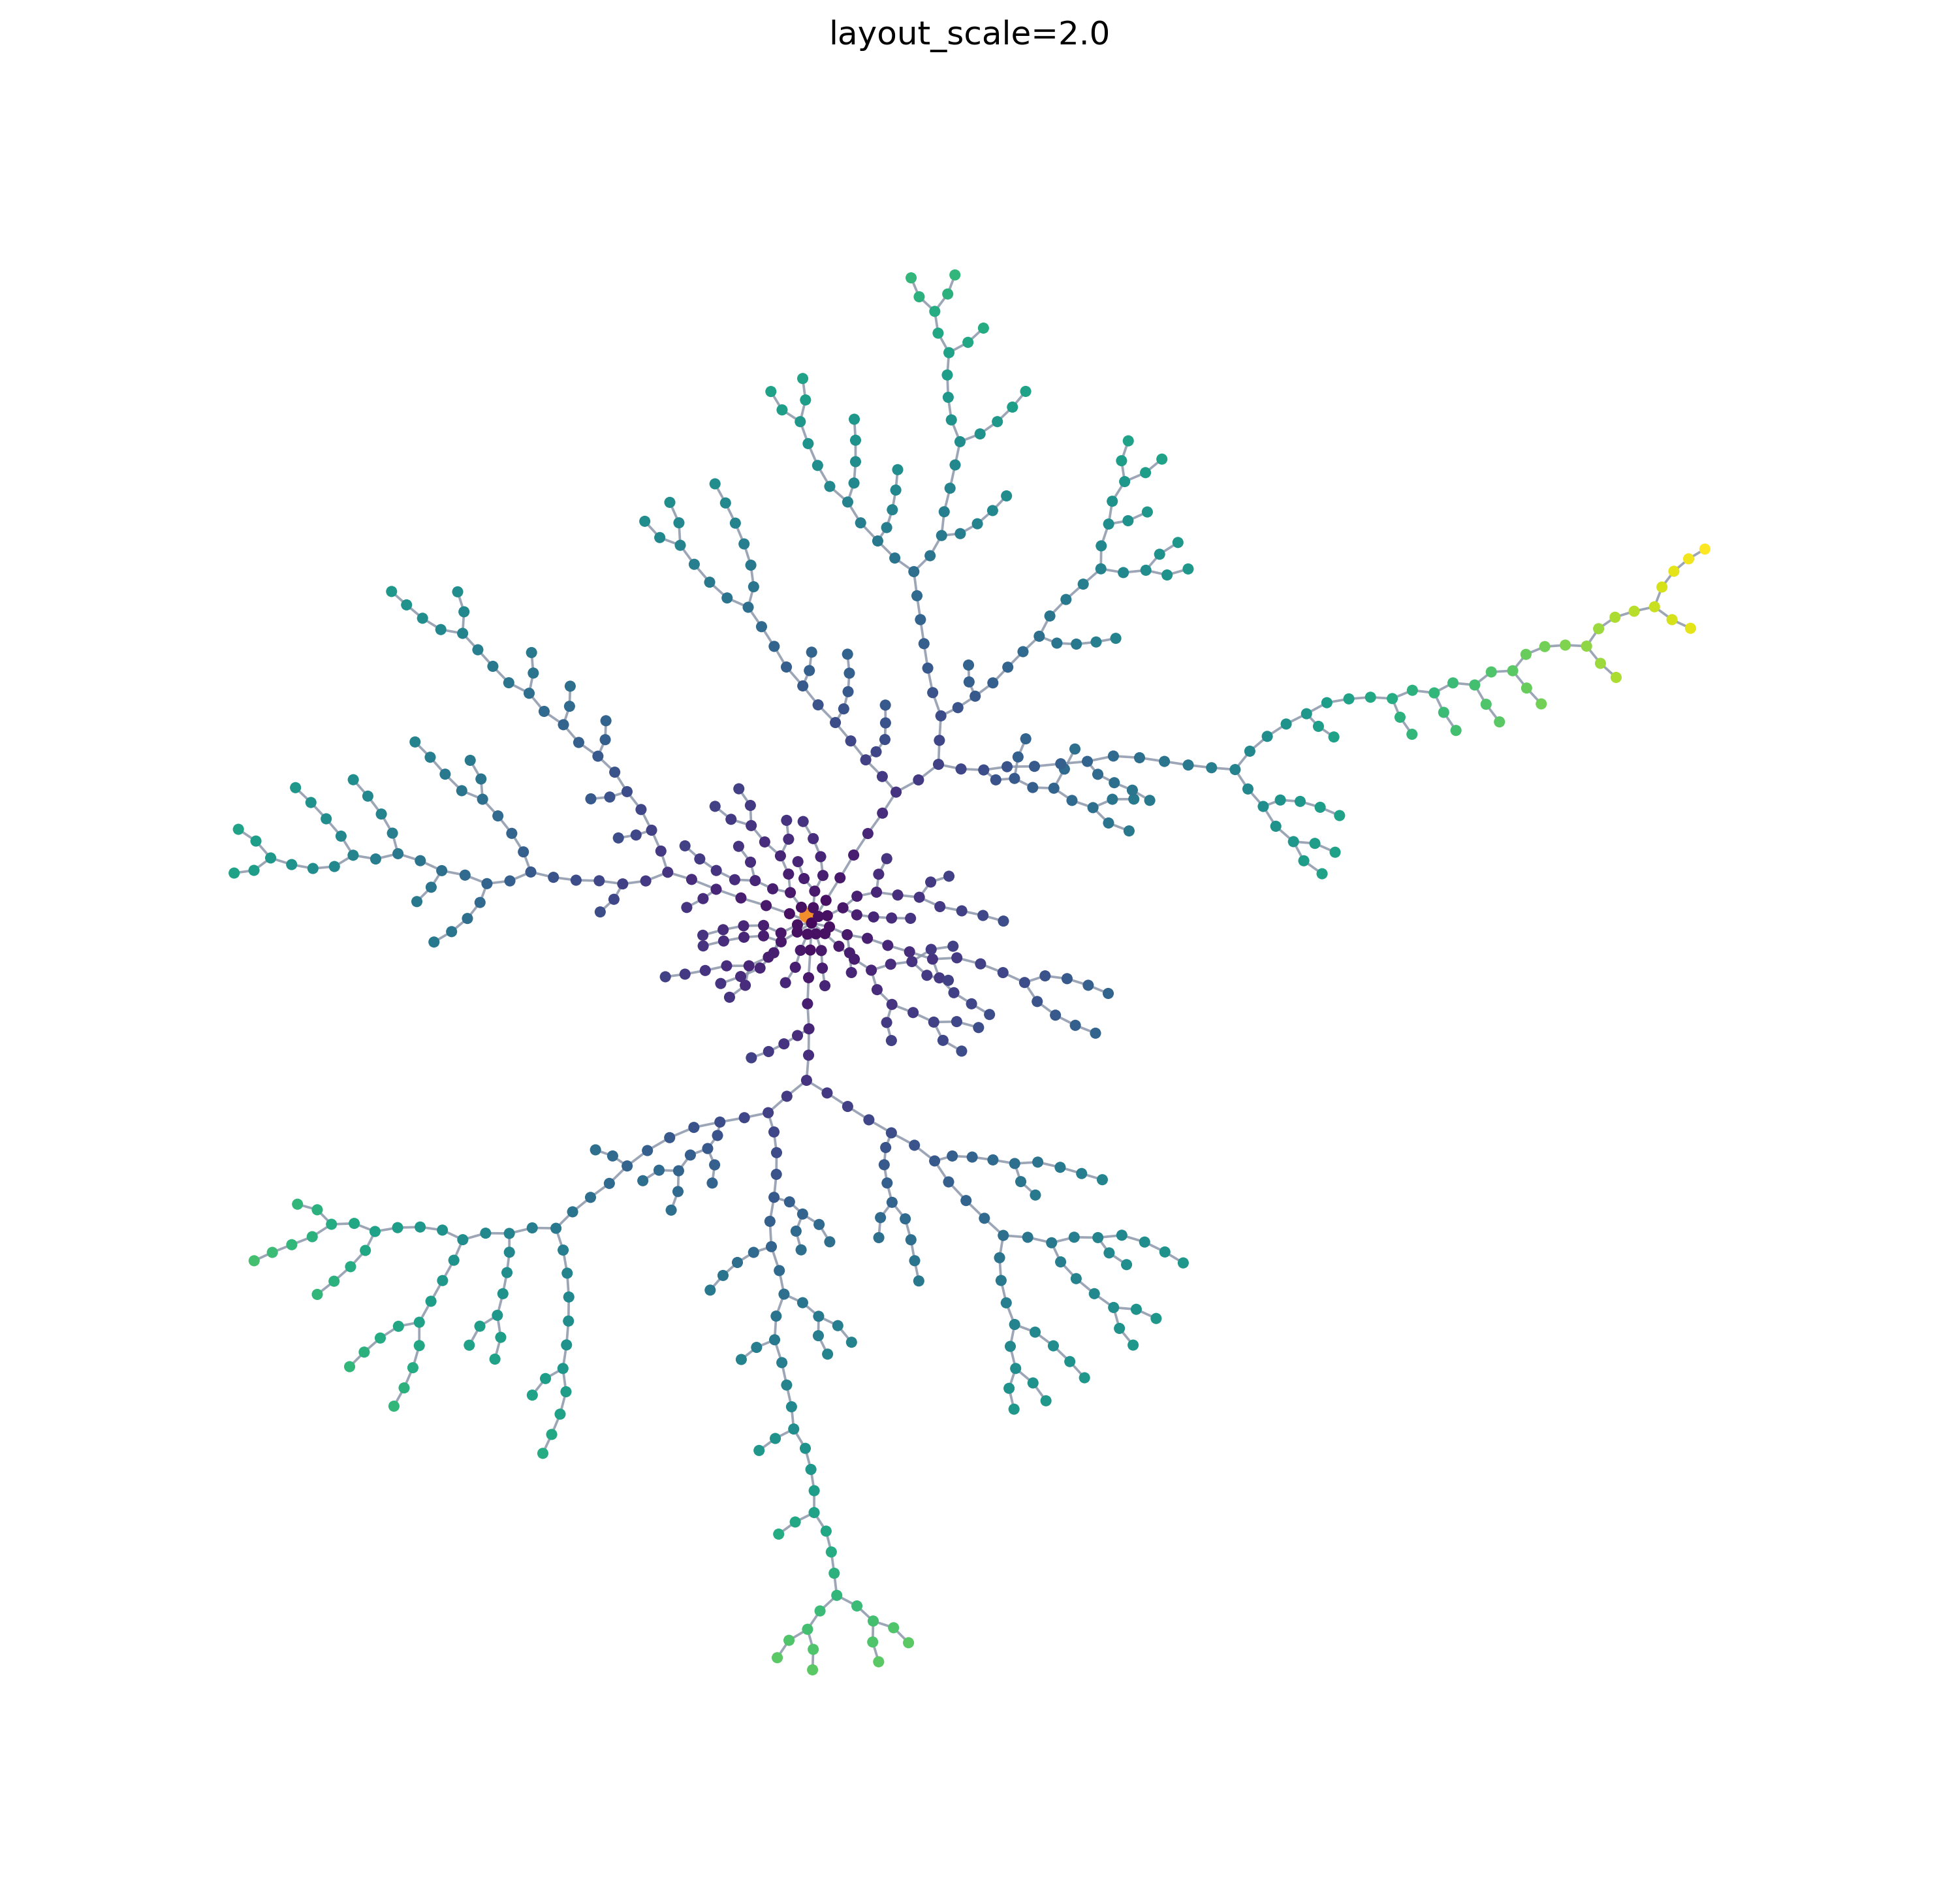

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)  # dpi=300 for high resolution

vis.plot_cell_topology(cell, preset="depth", layout="kamada_kawai", layout_scale=2.0, ax=ax)
ax.set_title("layout_scale=2.0")  

plt.tight_layout()
plt.show()

## 4. Color by custom point values

For low-level value mode, pass one scalar per point.

Below we compute a simple point-depth array from the root and use it as the colour source.


depth_values shape: (945,)
max depth: 51


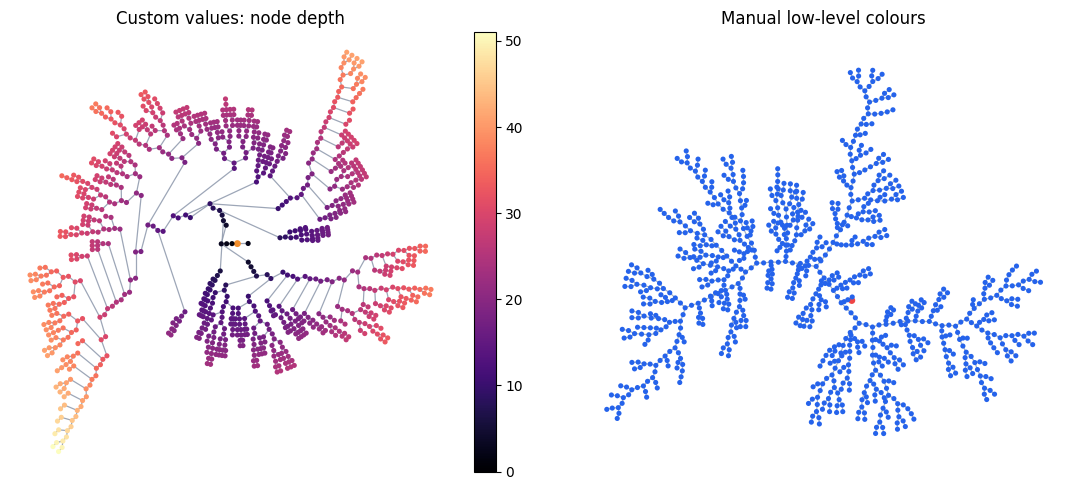

In [3]:
def node_depths(node_tree):
    depths = np.full(len(node_tree.nodes), np.nan, dtype=float)
    depths[node_tree.root_node_id] = 0.0
    children_by_node_id = {node.id: [] for node in node_tree.nodes}
    for edge in node_tree.edges:
        children_by_node_id[edge.parent_node_id].append(edge.child_node_id)
    queue = deque([node_tree.root_node_id])
    while queue:
        node_id = queue.popleft()
        for child_id in children_by_node_id[node_id]:
            depths[child_id] = depths[node_id] + 1.0
            queue.append(child_id)
    return depths


depth_values = node_depths(node_tree)
print("depth_values shape:", depth_values.shape)
print("max depth:", int(np.nanmax(depth_values)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vis.plot_cell_topology(cell,
    value=depth_values,
    cmap="magma",
    ax=axes[0],
)
axes[0].set_title("Custom values: node depth")

vis.plot_cell_topology(cell,
    layout="kamada_kawai",
    layout_scale=3.0,
    node_color="#2563eb",
    edge_color="#94a3b8",
    root_color="#ef4444",
    ax=axes[1],
)
axes[1].set_title("Manual low-level colours")

plt.tight_layout()
plt.show()


## 5. Cell-aware highlighting and runtime values

Node-level topology is the most detailed cell-facing view. It can:

- highlight points selected by a `region`
- highlight points selected by a `locset`
- colour by runtime voltage (`value="V"`)
- colour by mechanism fields such as `("channel", "IL", "g_max")`

Two important v1 rules:

- highlight mode and value mode are mutually exclusive
- `region` / `locset` are mapped to **CV midpoint points only**


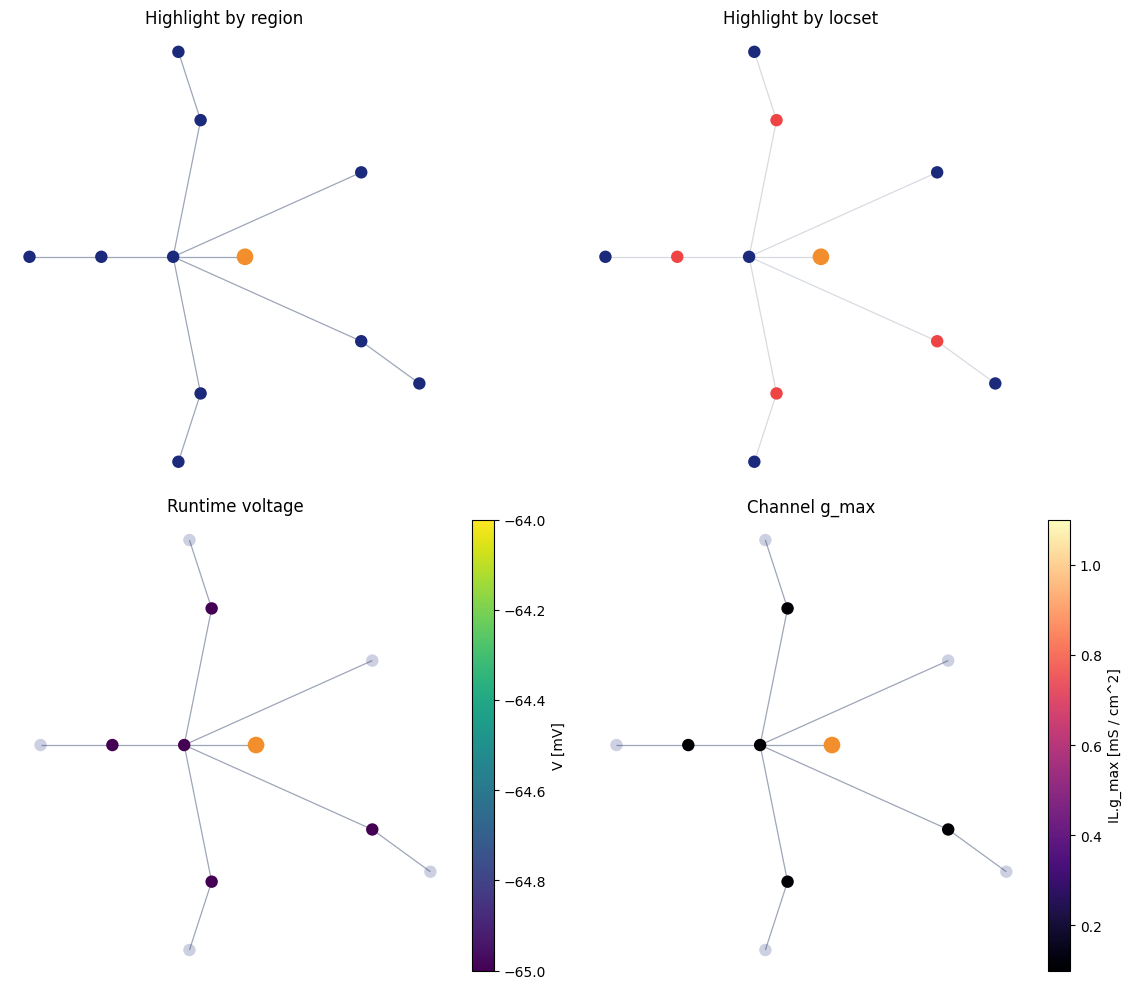

In [ ]:
cell.reset()
cell.paint(
    cell.paint_rules[0].region,
    mech.Channel("IL", g_max=0.1 * (u.mS / u.cm ** 2), E=-70.0 * u.mV),
)
cell.init_state()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

vis.plot_cell_topology(cell,
    region=BranchInFilter("type", "basal_dendrite"),
    ax=axes[0, 0],
)
axes[0, 0].set_title("Highlight by region")

vis.plot_cell_topology(cell,
    locset=Terminals(),
    ax=axes[0, 1],
)
axes[0, 1].set_title("Highlight by locset")

vis.plot_cell_topology(cell,
    value="V",
    cmap="viridis",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Runtime voltage")

vis.plot_cell_topology(cell,
    value=("channel", "IL", "g_max"),
    cmap="magma",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Channel g_max")

plt.tight_layout()
plt.show()


## 6. Parameter quick reference

### `vis.plot_cell_topology(cell, ...)`

- highlight mode: `region`, `locset`, `coverage_mode`, `highlight_color`
- value mode: `value`, `cmap`, `vmin`, `vmax`, `norm`, `value_label`, `show_colorbar`
- style: `node_color`, `edge_color`, `root_color`
- layout controls: `preset`, `layout`, `layout_scale`

### `vis.plot_cell_topology(cell, level="cv", ...)` / `vis.plot_cell_topology(cell, level="branch", ...)`

- `vis.plot_cell_topology(cell, level="cv", ...)`: same high-level API surface as `vis.plot_cell_topology(cell, ...)`
- `vis.plot_cell_topology(cell, level="branch", ...)`: region-only, no locset, no value colormap
- region coverage: `region`, `coverage_mode`, `highlight_color`
- style: `node_color`, `edge_color`, `root_color`
- layout controls: `preset`, `layout`, `layout_scale`

### Capability matrix

| Level | Region | Locset | Value | Coverage mode |
| --- | --- | --- | --- | --- |
| `node` | yes | yes | yes | yes |
| `cv` | yes | yes | yes | yes |
| `branch` | yes | no | no | yes |


### Highlight colour examples

Use `highlight_color` to change the overlay colour in highlight mode.


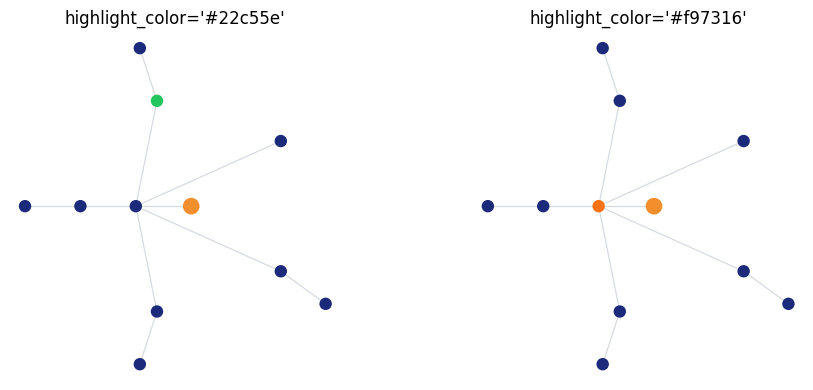

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vis.plot_cell_topology(cell,
    region=BranchSlice(branch_index=1, prox=0.0, dist=1.0),
    highlight_color="#22c55e",
    ax=axes[0],
)
axes[0].set_title("highlight_color='#22c55e'")

vis.plot_cell_topology(cell,
    locset=RootLocation(0.5),
    highlight_color="#f97316",
    ax=axes[1],
)
axes[1].set_title("highlight_color='#f97316'")

plt.tight_layout()
plt.show()


### Colormap and colorbar examples

Use `cmap`, `vmin`, `vmax`, `value_label`, and `show_colorbar` in value mode.


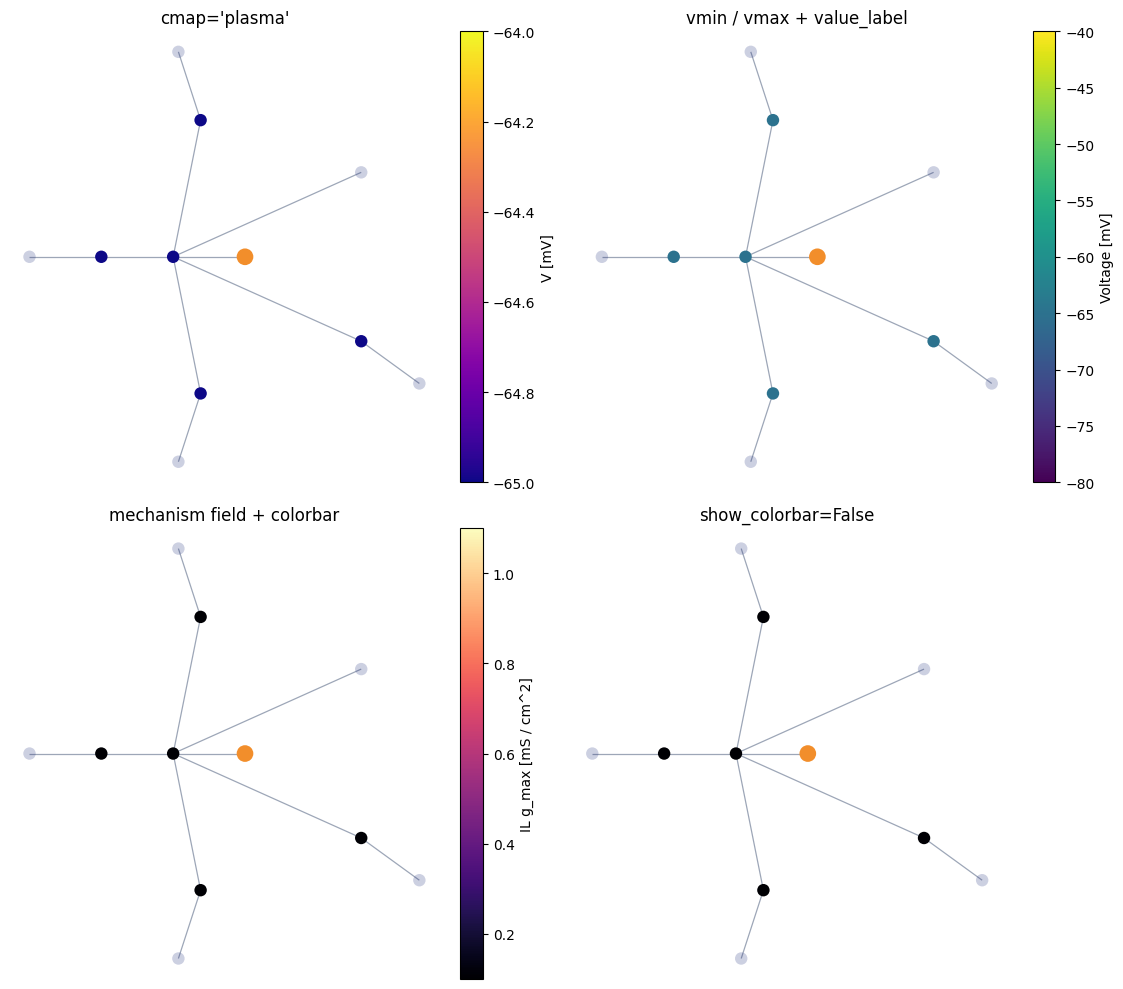

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

vis.plot_cell_topology(cell,
    value="V",
    cmap="plasma",
    ax=axes[0, 0],
)
axes[0, 0].set_title("cmap='plasma'")

vis.plot_cell_topology(cell,
    value="V",
    cmap="viridis",
    vmin=-80.0,
    vmax=-40.0,
    value_label="Voltage",
    ax=axes[0, 1],
)
axes[0, 1].set_title("vmin / vmax + value_label")

vis.plot_cell_topology(cell,
    value=("channel", "IL", "g_max"),
    cmap="magma",
    value_label="IL g_max",
    ax=axes[1, 0],
)
axes[1, 0].set_title("mechanism field + colorbar")

vis.plot_cell_topology(cell,
    value=("channel", "IL", "g_max"),
    cmap="magma",
    show_colorbar=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("show_colorbar=False")

plt.tight_layout()
plt.show()


### Low-level node / edge / root colours

These style controls are shared by the cell-level topology views.


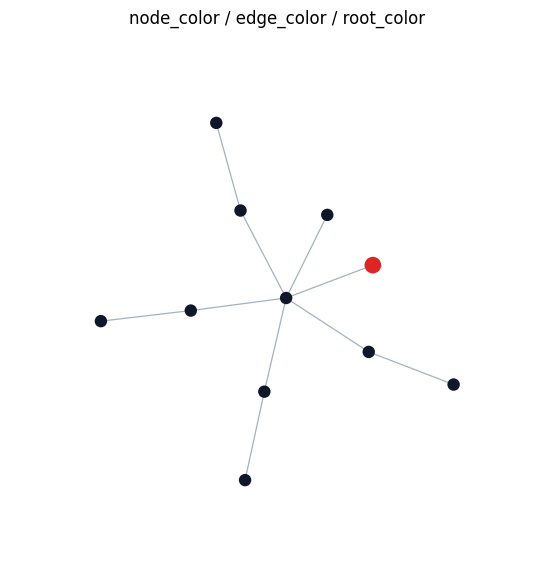

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
vis.plot_cell_topology(cell,
    layout="kamada_kawai",
    node_color="#0f172a",
    edge_color="#94a3b8",
    root_color="#dc2626",
    ax=ax,
)
ax.set_title("node_color / edge_color / root_color")
plt.show()


## 7. CV-level topology view

You can also collapse the runtime graph upward and show **one node per CV**.

This view now shares the same high-level API surface as `vis.plot_cell_topology(cell, ...)`,
but it is often most useful as a pure topology + coverage view.

Coverage is still controlled with:

- `coverage_mode="fraction"`: blend by coverage fraction
- `coverage_mode="any"`: any overlap gives full highlight
- `coverage_mode="all"`: only full coverage highlights


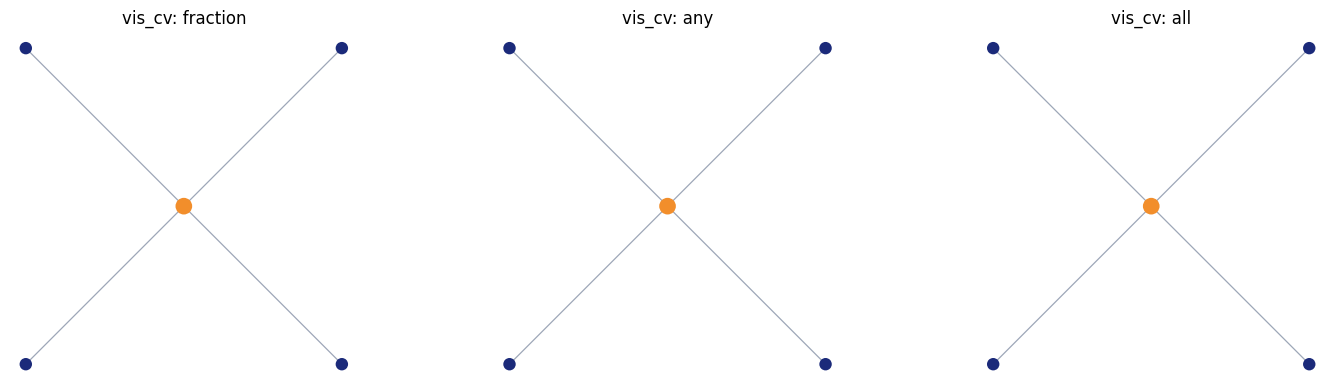

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

region = BranchInFilter("type", "basal_dendrite")

vis.plot_cell_topology(cell, level="cv", region=region, coverage_mode="fraction", ax=axes[0])
axes[0].set_title("level='cv': fraction")

vis.plot_cell_topology(cell, level="cv", region=region, coverage_mode="any", ax=axes[1])
axes[1].set_title("level='cv': any")

vis.plot_cell_topology(cell, level="cv", region=region, coverage_mode="all", ax=axes[2])
axes[2].set_title("level='cv': all")

plt.tight_layout()
plt.show()


## 8. Branch-level topology view

At a higher level, you can show **one node per branch**.

This remains topology-only and region-only.


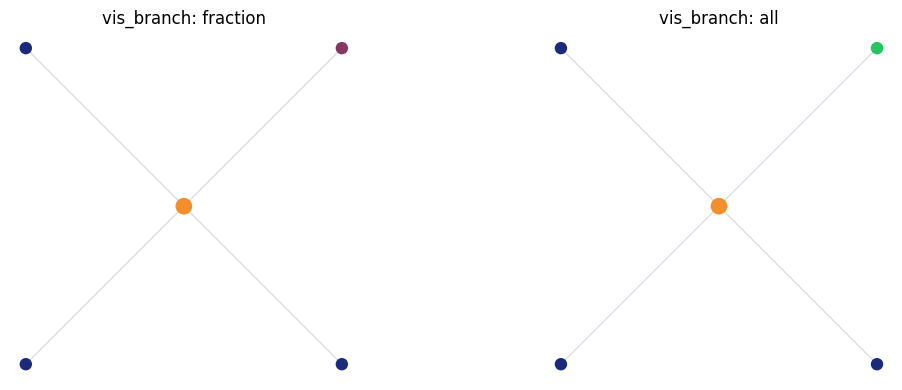

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vis.plot_cell_topology(cell,
    level="branch",
    region=BranchSlice(branch_index=1, prox=0.25, dist=0.75),
    coverage_mode="fraction",
    ax=axes[0],
)
axes[0].set_title("level='branch': fraction")

vis.plot_cell_topology(cell,
    level="branch",
    region=BranchSlice(branch_index=1, prox=0.0, dist=1.0),
    coverage_mode="all",
    highlight_color="#22c55e",
    ax=axes[1],
)
axes[1].set_title("level='branch': all")

plt.tight_layout()
plt.show()
